In [13]:
import os
import platform
import subprocess
import re

import numpy as np
from scipy.stats import norm
import arviz as az
import pymc as pm
import pytensor.tensor as at
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any, Union


import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
az.style.use("arviz-doc")

In [15]:
error_data = [
    96.6, 38.3, 80.8, 15.1, 34, 73.4, 14.5, 64.8, 27.4, 48.7,
    43.3, 43.4, 57.8, 94.9, 44.1, 44.3, 62.9, 117, 51.6, 64.7,
    50.1, 74.7, 221, 46.8, 84.3, 93.4, 126, 46.9, 29.5, 73.8,
    66.9, 61.3, 30.2, 101, 22.6, 191, 29.3, 68, 114, 33.7,
    52.5, 118, 49.7, 60.4, 36.6, 55.9, 31.9, 84.3, 75.8, 39.5,
    28.3, 56.5, 44.2, 48, 36.6, 70, 37, 72, 48, 66.1,
    72.4, 80.9, 69.1, 162, 67.3, 75.2, 40.5, 25.6, 44, 120,
    56.3, 42.9, 6.63, 24.9, 40.9, 81, 97.2, 74.7, 79.6, 48.8,
    75.3, 54.8, 66.5, 71.3, 28.7, 87.5, 51.9, 19.6, 60.8, 45.9,
    46.9, 84.8, 120, 103, 36.7, 92.7, 32.8, 73.8, 214, 65.3
]

# OEL of 100
error_data = np.array(error_data) / 100

# Helper Functions

### System Utils

In [16]:
def get_processor_name():
    if platform.system() == "Windows":
        return platform.processor()
    elif platform.system() == "Darwin":
        os.environ['PATH'] = os.environ['PATH'] + os.pathsep + '/usr/sbin'
        command ="sysctl -n machdep.cpu.brand_string"
        return subprocess.check_output(command).strip()
    elif platform.system() == "Linux":
        command = "cat /proc/cpuinfo"
        all_info = subprocess.check_output(command, shell=True).decode().strip()
        for line in all_info.split("\n"):
            if "model name" in line:
                return re.sub( ".*model name.*:", "", line,1)
    return ""

### Data Processing

In [17]:
@dataclass
class CensoredData:
    y: List[float]
    lower_limits: List[float]
    upper_limits: List[float]
    uncensored_data: List[float]
    censored_data: List[float]
    censored_limits: List[float]

def define_observed_lower_upper(expo_data: List[str], oel:float) -> CensoredData:
    y = []
    lower_limits = []
    upper_limits = []

    for value in expo_data:
        if value.startswith('<'):
            # Left-censored
            limit = float(value[1:])  # Extract the numeric value
            y.append(limit)
            lower_limits.append(limit)
            upper_limits.append(np.inf)
        elif value.startswith('>'):
            # Right-censored
            limit = float(value[1:])  # Extract the numeric value
            y.append(limit)
            lower_limits.append(-np.inf)
            upper_limits.append(limit)
        elif '-' in value:
            # Interval-censored
            lower, upper = map(float, value.split('-'))  # Extract the range
            y.append((lower + upper) / 2)
            lower_limits.append(lower)
            upper_limits.append(upper)
        else:
            # Uncensored
            y.append(float(value))
            lower_limits.append(-np.inf)
            upper_limits.append(np.inf)
        
    # Divide all values by the OEL, excluding infinite values
    y = [value / oel if value != np.inf and value != -np.inf else value for value in y]
    lower_limits = [value / oel if value != np.inf and value != -np.inf else value for value in lower_limits]
    upper_limits = [value / oel if value != np.inf and value != -np.inf else value for value in upper_limits]
    
    # Separate the data into two additional lists for censored and uncensored data, using the lower and upper limits as index for y
    uncensored_data = [value for value in y if value in lower_limits or value in upper_limits]
    censored_limits = [value for value in lower_limits if value in uncensored_data] + [value for value in upper_limits if value in uncensored_data]
    censored_data = [value for value in y if value not in uncensored_data]
    
    
    return CensoredData(y, lower_limits, upper_limits, censored_data, uncensored_data, censored_limits)

### Mu and sigma chain calculations

In [18]:
# Function to return the mu and sigma chains and also add the log(oel) to each chain for the mu 
def extract_chains(trace: az.InferenceData, oel: float) -> Tuple[np.ndarray, np.ndarray]:
    mu_chain = trace.posterior["mu"].values.flatten()
    sigma_chain = trace.posterior["sigma"].values.flatten()
    
    # Add log(oel) to each element in the mu chain
    mu_chain += np.log(oel)
    
    return mu_chain, sigma_chain

In [19]:
# Helper function for calculating statistics
def calculate_stats(chain: np.ndarray, probacred: float, precision: int = 3) -> Dict[str, float]:
    lower = (100 - probacred) / 200
    upper = 1 - lower
    return {
        "est": round(np.median(chain), precision),
        "lcl": round(np.quantile(chain, lower), precision),
        "ucl": round(np.quantile(chain, upper), precision),
    }

# Geometric mean
def geometric_mean(mu_chain: np.ndarray, probacred: float, precision: int = 3) -> Dict[str, float]:
    return calculate_stats(np.exp(mu_chain), probacred, precision)

# Geometric standard deviation
def geometric_sd(sigma_chain: np.ndarray, probacred: float, precision: int = 3) -> Dict[str, float]:
    return calculate_stats(np.exp(sigma_chain), probacred, precision)

# Exceedance fraction
def exceedance_fraction(mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, oel: float, precision: int = 3) -> Dict[str, float]:
    chain = 100 * (1 - norm.cdf((np.log(oel) - mu_chain) / sigma_chain))
    return calculate_stats(chain, probacred, precision)

# Percentile of interest
def percentile_of_interest(mu_chain: np.ndarray, sigma_chain: np.ndarray, target_perc: float, probacred: float, precision: int = 3) -> Dict[str, float]:
    chain = np.exp(mu_chain + norm.ppf(target_perc / 100) * sigma_chain)
    return calculate_stats(chain, probacred, precision)

# Arithmetic mean
def arithmetic_mean(mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, precision: int = 3) -> Dict[str, float]:
    chain = np.exp(mu_chain + 0.5 * sigma_chain**2)
    return calculate_stats(chain, probacred, precision)

# Fractional risk
def frac_risk(mu_chain: np.ndarray, sigma_chain: np.ndarray, frac_threshold: float, oel: float, precision: int = 3) -> float:
    chain = 100 * (1 - norm.cdf((np.log(oel) - mu_chain) / sigma_chain))
    return round(100 * np.sum(chain > frac_threshold) / len(chain), precision)

# Percentile risk
def perc_risk(mu_chain: np.ndarray, sigma_chain: np.ndarray, target_perc: float, oel: float, precision: int = 3) -> float:
    chain = np.exp(mu_chain + norm.ppf(target_perc / 100) * sigma_chain)
    return round(100 * np.sum(chain > oel) / len(chain), precision)

# Arithmetic mean risk
def am_risk(mu_chain: np.ndarray, sigma_chain: np.ndarray, oel: float, precision: int = 3) -> float:
    chain = np.exp(mu_chain + 0.5 * sigma_chain**2)
    return round(100 * np.sum(chain > oel) / len(chain), precision)

# Risk bands for arithmetic mean
def am_riskbands(mu_chain: np.ndarray, sigma_chain: np.ndarray, oel: float, precision: int = 3) -> Dict[str, float]:
    chain = np.exp(mu_chain + 0.5 * sigma_chain**2)
    riskbands = 100 * np.histogram(chain, bins=[np.exp(-20), 0.01 * oel, 0.1 * oel, 0.5 * oel, oel, np.exp(20) * oel])[0] / len(chain)
    categories = ["<0.01*OEL", "[0.01-0.1]*OEL", "[0.1-0.5]*OEL", "[0.5-1]*OEL", ">OEL"]
    return {category: round(risk, precision) for category, risk in zip(categories, riskbands)}

In [20]:
# Aggregate all numeric results
def all_numeric(mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, oel: float, frac_threshold: float, target_perc: float, precision: int = 3) -> Dict[str, Union[Dict[str, float], float]]:
    return {
        "gm": geometric_mean(mu_chain, probacred, precision),
        "gsd": geometric_sd(sigma_chain, probacred, precision),
        "frac": exceedance_fraction(mu_chain, sigma_chain, probacred, oel, precision),
        "perc": percentile_of_interest(mu_chain, sigma_chain, target_perc, probacred, precision),
        "am": arithmetic_mean(mu_chain, sigma_chain, probacred, precision),
        "frac.risk": frac_risk(mu_chain, sigma_chain, frac_threshold, oel, precision),
        "perc.risk": perc_risk(mu_chain, sigma_chain, target_perc, oel, precision),
        "am.risk": am_risk(mu_chain, sigma_chain, oel, precision),
        "am.riskbands": am_riskbands(mu_chain, sigma_chain, oel, precision),
    }

# Interpretation function
def interpretation(is_lognormal: bool, mu_chain: np.ndarray, sigma_chain: np.ndarray, probacred: float, oel: float, frac_threshold: float, target_perc: float, precision: int = 3) -> Dict[str, Union[Dict[str, float], float]]:
    if is_lognormal:
        return all_numeric(mu_chain, sigma_chain, probacred, oel, frac_threshold, target_perc, precision)
    else:
        raise NotImplementedError("Normal model interpretation is not implemented yet.")

# Informedvar model 

In [21]:
with pm.Model() as cv_error_model:
    # Data
    y_data = pm.Data("y_data", error_data)

    # Priors
    mu = pm.Uniform("mu", lower=-10.0, upper=10.0)  # Prior for mean of lognormal
    log_sigma = pm.Normal("log_sigma", mu=-0.1744, sigma=1/pm.math.sqrt(2.5523))  # Prior for log(sigma)
    sigma = pm.Deterministic("sigma", pm.math.exp(log_sigma))  # Convert log_sigma to sigma

    # Prior on CV (Coefficient of Variation)
    cv = pm.Uniform("Error (CV)", lower=0.15, upper=0.45)  # Adjust bounds as necessary

    # Likelihood with CV-dependent measurement error
    true_data = pm.Lognormal("true_data", mu=mu, sigma=sigma, shape=y_data.shape)  # True values

    # Define measurement error precision using CV
    meas_error_precision = pm.Deterministic("MeasErrorPrecision", (1 / (cv * true_data)**2))

    censored_observations = pm.Censored(
        "y with censoring",
        pm.Normal.dist(mu=true_data, tau=meas_error_precision, shape=y_data.shape),
        lower=None,
        upper=None,
        observed=y_data
    )

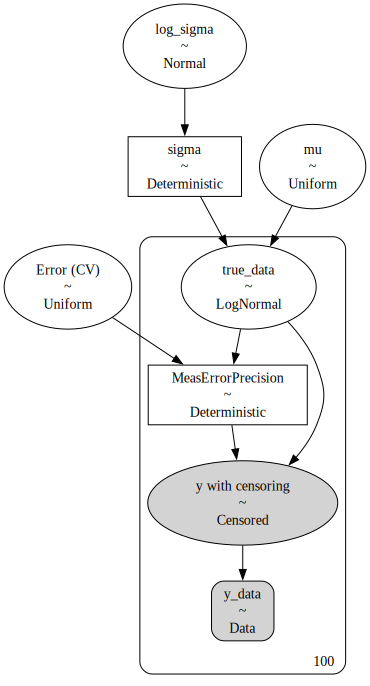

In [22]:
pm.model_to_graphviz(cv_error_model)

### Normal PyMC

In [23]:
%%time
with cv_error_model:
    error_pypc_trace = pm.sample(
        draws=15000,
        tune=5000,
        chains=4,
        return_inferencedata=True,
        initvals={
            "mu": np.log(0.3), 
            "log_sigma": np.log(2.5)
            }
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, log_sigma, Error (CV), true_data]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 38 seconds.


CPU times: user 15.2 s, sys: 2.13 s, total: 17.3 s
Wall time: 43 s


In [24]:
%%time
with cv_error_model:
    error_blackjax_trace = pm.sample(
        draws=15000,
        tune=5000,
        chains=4,
        return_inferencedata=True,
        initvals={
            "mu": np.log(0.3), 
            "log_sigma": np.log(2.5)
            },
        nuts_sampler='blackjax'
    )

Running window adaptation


CPU times: user 33 s, sys: 2.39 s, total: 35.4 s
Wall time: 14.9 s


In [25]:
%%time
with cv_error_model:
    error_nutpie_trace = pm.sample(
        draws=15000,
        tune=5000,
        chains=4,
        return_inferencedata=True,
        initvals={
            "mu": np.log(0.3), 
            "log_sigma": np.log(2.5)
            },
        nuts_sampler='nutpie'
    )

/opt/conda/lib/python3.11/site-packages/pymc/sampling/mcmc.py:317: UserWarning: `initvals` are currently not passed to nutpie sampler. Use `init_mean` kwarg following nutpie specification instead.
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,20000,0,0.43,7
,20000,0,0.43,15
,20000,0,0.43,15
,20000,0,0.41,7


CPU times: user 30.7 s, sys: 554 ms, total: 31.3 s
Wall time: 24.6 s


In [26]:
%%time
with cv_error_model:
    error_numpyro_trace = pm.sample(
        draws=15000,
        tune=5000,
        chains=4,
        return_inferencedata=True,
        initvals={
            "mu": np.log(0.3), 
            "log_sigma": np.log(2.5)
            },
        nuts_sampler='numpyro'
    )

  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

CPU times: user 35.8 s, sys: 1.88 s, total: 37.7 s
Wall time: 14.3 s


In [27]:
error_pypc_mu_chain, error_pypc_sigma_chain = extract_chains(error_pypc_trace, 100)

interpretation(
    is_lognormal=True,
    mu_chain=error_pypc_mu_chain,
    sigma_chain=error_pypc_sigma_chain,
    probacred=90,
    oel=100,
    frac_threshold=5,
    target_perc=95
)

{'gm': {'est': 59.515, 'lcl': 54.15, 'ucl': 65.3},
 'gsd': {'est': 1.541, 'lcl': 1.398, 'ucl': 1.727},
 'frac': {'est': 11.498, 'lcl': 5.91, 'ucl': 18.099},
 'perc': {'est': 121.261, 'lcl': 102.961, 'ucl': 146.542},
 'am': {'est': 65.447, 'lcl': 59.801, 'ucl': 72.226},
 'frac.risk': 97.465,
 'perc.risk': 97.465,
 'am.risk': 0.0,
 'am.riskbands': {'<0.01*OEL': 0.0,
  '[0.01-0.1]*OEL': 0.0,
  '[0.1-0.5]*OEL': 0.0,
  '[0.5-1]*OEL': 100.0,
  '>OEL': 0.0}}

In [28]:
error_blackjax_mu_chain, error_blackjax_sigma_chain = extract_chains(error_blackjax_trace, 100)

interpretation(
    is_lognormal=True,
    mu_chain=error_blackjax_mu_chain,
    sigma_chain=error_blackjax_sigma_chain,
    probacred=90,
    oel=100,
    frac_threshold=5,
    target_perc=95
)

{'gm': {'est': 59.511, 'lcl': 54.165, 'ucl': 65.254},
 'gsd': {'est': 1.542, 'lcl': 1.399, 'ucl': 1.727},
 'frac': {'est': 11.523, 'lcl': 5.942, 'ucl': 18.07},
 'perc': {'est': 121.301, 'lcl': 103.036, 'ucl': 146.507},
 'am': {'est': 65.471, 'lcl': 59.838, 'ucl': 72.153},
 'frac.risk': 97.553,
 'perc.risk': 97.553,
 'am.risk': 0.0,
 'am.riskbands': {'<0.01*OEL': 0.0,
  '[0.01-0.1]*OEL': 0.0,
  '[0.1-0.5]*OEL': 0.0,
  '[0.5-1]*OEL': 100.0,
  '>OEL': 0.0}}

In [29]:
error_nutpie_mu_chain, error_nutpie_sigma_chain = extract_chains(error_numpyro_trace, 100)

interpretation(
    is_lognormal=True,
    mu_chain=error_nutpie_mu_chain,
    sigma_chain=error_nutpie_sigma_chain,
    probacred=90,
    oel=100,
    frac_threshold=5,
    target_perc=95
)

{'gm': {'est': 59.537, 'lcl': 54.106, 'ucl': 65.309},
 'gsd': {'est': 1.541, 'lcl': 1.398, 'ucl': 1.725},
 'frac': {'est': 11.517, 'lcl': 5.924, 'ucl': 18.122},
 'perc': {'est': 121.217, 'lcl': 102.993, 'ucl': 146.52},
 'am': {'est': 65.476, 'lcl': 59.803, 'ucl': 72.25},
 'frac.risk': 97.508,
 'perc.risk': 97.508,
 'am.risk': 0.0,
 'am.riskbands': {'<0.01*OEL': 0.0,
  '[0.01-0.1]*OEL': 0.0,
  '[0.1-0.5]*OEL': 0.0,
  '[0.5-1]*OEL': 100.0,
  '>OEL': 0.0}}

In [30]:
error_nutpie_mu_chain, error_nutpie_sigma_chain = extract_chains(error_nutpie_trace, 100)

interpretation(
    is_lognormal=True,
    mu_chain=error_nutpie_mu_chain,
    sigma_chain=error_nutpie_sigma_chain,
    probacred=90,
    oel=100,
    frac_threshold=5,
    target_perc=95
)

{'gm': {'est': 59.519, 'lcl': 54.149, 'ucl': 65.303},
 'gsd': {'est': 1.541, 'lcl': 1.397, 'ucl': 1.727},
 'frac': {'est': 11.505, 'lcl': 5.885, 'ucl': 18.097},
 'perc': {'est': 121.261, 'lcl': 102.837, 'ucl': 146.521},
 'am': {'est': 65.477, 'lcl': 59.812, 'ucl': 72.196},
 'frac.risk': 97.38,
 'perc.risk': 97.38,
 'am.risk': 0.0,
 'am.riskbands': {'<0.01*OEL': 0.0,
  '[0.01-0.1]*OEL': 0.0,
  '[0.1-0.5]*OEL': 0.0,
  '[0.5-1]*OEL': 100.0,
  '>OEL': 0.0}}

In [32]:
# Run Time Check

import logging
import timeit
logger = logging.getLogger("pymc")
logger.propagate = False

In [33]:
num_interations = 25

def run_model(sampler:str, model:pm.Model) -> None:
    with model:
        if sampler == 'blackjax':
            error_blackjax_trace = pm.sample(
                draws=25000,
                tune=5000,
                chains=4,
                return_inferencedata=True,
                nuts_sampler='blackjax',
                show_progressbar=False
            )
        elif sampler == 'nutpie':
            error_nutpie_trace = pm.sample(
                draws=25000,
                tune=5000,
                chains=4,
                return_inferencedata=True,
                nuts_sampler='nutpie',
                show_progressbar=False
            )
        elif sampler == 'numpyro':
            error_pypc_trace = pm.sample(
                draws=25000,
                tune=5000,
                chains=4,
                return_inferencedata=True,
                show_progressbar=False,
                nuts_sampler='numpyro'
            )
        else:
            "Invalid sampler"

In [36]:
%%capture
list_time: float = timeit.timeit(stmt='run_model("blackjax", cv_error_model)', number=num_interations, globals=globals())

In [37]:
print(f"Average time for blackjax: {list_time / num_interations:.2f} seconds")

Average time for blackjax: 18.60 seconds


In [40]:
%%capture
numpyro_time: float = timeit.timeit(stmt='run_model("numpyro", cv_error_model)', number=num_interations, globals=globals())

In [41]:
print(f"Average time for numpyro: {numpyro_time / num_interations:.2f} seconds")

Average time for numpyro: 18.38 seconds


In [ ]:
%%capture
nutpie_time: float = timeit.timeit(stmt='run_model("nutpie", cv_error_model)', number=num_interations, globals=globals())

In [39]:
print(f"Average time for nutpie: {nutpie_time / num_interations:.2f} seconds")

NameError: name 'nutpie_time' is not defined